# Predicting English Premier League Match Outcomes (2015–2025)

This project uses machine learning to predict English Premier League (EPL) match outcomes (**Home Win**, **Draw**, **Away Win**) from historical match statistics (2015–2025).

We will:
- Load and filter the dataset to **Premier League** matches only.
- Explore the data with **charts** (class balance, stats by result, trends, home win rates).
- Conduct **statistical analysis** including hypothesis testing.
- Build and evaluate **Random Forest**, **Logistic Regression**, and **XGBoost** classifiers.
- Interpret results with a **confusion matrix**, **feature importance**, and **model comparison** chart.

---

| Section | Content |
|---------|----------|
| 1 | Imports & Configuration |
| 2 | Load & Inspect Data |
| 3 | Filter to EPL & Basic Cleaning |
| 4 | Target & Feature Design |
| 5 | Exploratory Data Analysis |
| 6 | Statistical Analysis |
| 7 | Train / Test Split & Preprocessing |
| 8 | Model Training |
| 9 | Model Evaluation (Confusion Matrices) |
| 10 | Feature Importance |
| 11 | Model Comparison |
| 12 | Conclusions & Recommendations |


---
## Section 1 — Imports & Configuration

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# All library imports live here. Run this cell first.
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy  as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import chi2_contingency, kruskal

from sklearn.model_selection  import train_test_split
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import OneHotEncoder
from sklearn.pipeline         import Pipeline
from sklearn.impute           import SimpleImputer
from sklearn.metrics          import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score
)
from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from xgboost import XGBClassifier


# ── Global style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (9, 5)})
PALETTE = ['#2196F3', '#9E9E9E', '#F44336']   # Blue=Home, Grey=Draw, Red=Away
RANDOM_STATE = 42



---
## Section 2 — Load and Inspect Data

We load the full football results dataset (`Football_Dataset_2015_2025.csv`) and inspect its shape, column types, and first rows. The raw dataset contains 3,000 rows across multiple competitions.

In [21]:
# ═══ REPORT SCREENSHOT — Section 4.1: df.info() and df.head() ═══
# ──────────────────────────────────────────────────────────────────────────────
# Load the dataset. Date column is parsed automatically.
# ──────────────────────────────────────────────────────────────────────────────
DATA_PATH = 'Football_Dataset_2015_2025.csv'

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print(f'Rows   : {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
print('\n--- Column Types ---')
df.info()
df.head()

Rows   : 3,000
Columns: ['Date', 'Competition', 'Home Team', 'Away Team', 'Home Goals', 'Away Goals', 'Possession % (Home)', 'Possession % (Away)', 'Shots (Home)', 'Shots (Away)', 'Corners (Home)', 'Corners (Away)', 'Fouls (Home)', 'Fouls (Away)', 'Winner', 'Year']

--- Column Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 3000 non-null   datetime64[ns]
 1   Competition          3000 non-null   object        
 2   Home Team            3000 non-null   object        
 3   Away Team            3000 non-null   object        
 4   Home Goals           3000 non-null   int64         
 5   Away Goals           3000 non-null   int64         
 6   Possession % (Home)  3000 non-null   int64         
 7   Possession % (Away)  3000 non-null   int64         
 8   Shots (Home)         3000 non-

,Date,Competition,Home Team,Away Team,Home Goals,Away Goals,Possession % (Home),Possession % (Away),Shots (Home),Shots (Away),Corners (Home),Corners (Away),Fouls (Home),Fouls (Away),Winner,Year
0,2015-12-12,La Liga,Barcelona,AC Milan,3,1,44,52,15,20,7,2,12,15,Away Team,2021
1,2022-07-20,La Liga,Barcelona,Bayern Munich,0,5,52,42,23,19,4,10,13,7,Away Team,2015
2,2021-03-08,La Liga,Manchester City,Bayern Munich,2,5,55,58,18,16,5,9,7,10,Home Team,2016
3,2022-12-08,Bundesliga,Bayern Munich,Man City,5,1,63,40,8,12,2,3,15,8,Away Team,2017
4,2016-08-24,Bundesliga,Barcelona,Juventus,0,1,41,57,9,12,4,7,11,9,Away Team,2015


---
## Section 3 — Filter to EPL & Basic Cleaning

We keep only `Competition == "Premier League"` rows, drop rows missing the `Winner` or `Date`, and convert `Year` to numeric. After filtering, the dataset is reduced to **591 EPL matches** across 11 seasons (2015–2025).

In [22]:
# ═══ REPORT SCREENSHOT — Section 4.1: Missing Values & Cleaning Summary ═══
# ──────────────────────────────────────────────────────────────────────────────
# Filter to EPL, drop critical nulls, coerce Year.
# ──────────────────────────────────────────────────────────────────────────────
epl = df[df['Competition'] == 'Premier League'].copy()
epl = epl.dropna(subset=['Winner', 'Date'])
epl['Year'] = pd.to_numeric(epl['Year'], errors='coerce')

print(f'EPL rows after filtering : {len(epl):,}')
print(f'Seasons covered          : {sorted(epl["Year"].dropna().astype(int).unique().tolist())}')
print('\n--- Winner Distribution ---')
print(epl['Winner'].value_counts())

# Missing values per column
miss = epl.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print('\n--- Missing Values ---')
print(miss if not miss.empty else 'No missing values.')

epl.head()

EPL rows after filtering : 591
Seasons covered          : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

--- Winner Distribution ---
Winner
Away Team    214
Draw         194
Home Team    183
Name: count, dtype: int64

--- Missing Values ---
No missing values.


,Date,Competition,Home Team,Away Team,Home Goals,Away Goals,Possession % (Home),Possession % (Away),Shots (Home),Shots (Away),Corners (Home),Corners (Away),Fouls (Home),Fouls (Away),Winner,Year
8,2023-12-25,Premier League,Chelsea,Arsenal,1,2,67,40,25,12,2,6,11,10,Home Team,2021
12,2021-12-27,Premier League,Chelsea,Arsenal,3,1,61,51,10,15,10,5,6,8,Away Team,2018
14,2016-06-06,Premier League,Manchester City,Chelsea,3,1,60,46,19,9,8,3,11,15,Away Team,2021
26,2025-11-15,Premier League,PSG,Paris Saint-Germain,4,0,70,32,6,11,8,8,5,12,Away Team,2023
27,2020-07-22,Premier League,Bayern Munich,Borussia Dortmund,5,4,67,48,14,19,7,9,7,9,Draw,2016


---
## Section 4 — Target & Feature Design

- **Target (`y`)**: `Winner` — three classes: `Home Team`, `Draw`, `Away Team`.
- **Features (`X`)**: Match statistics (Possession, Shots, Corners, Fouls), team identities (Home Team / Away Team), and date-derived temporal features (Month, DayOfWeek, Year).
- **Goal columns are intentionally excluded** — Home Goals and Away Goals directly determine the winner and would constitute data leakage.

In [23]:
# ──────────────────────────────────────────────────────────────────────────────
# Feature matrix and target definition.
# Month and DayOfWeek capture seasonal and weekly scheduling effects.
# ──────────────────────────────────────────────────────────────────────────────

# Date-derived features
epl['Month']      = epl['Date'].dt.month
epl['DayOfWeek']  = epl['Date'].dt.dayofweek

feature_cols = [
    'Home Team', 'Away Team',
    'Year',
    'Possession % (Home)', 'Possession % (Away)',
    'Shots (Home)',        'Shots (Away)',
    'Corners (Home)',      'Corners (Away)',
    'Fouls (Home)',        'Fouls (Away)',
    'Month', 'DayOfWeek',
]

X = epl[feature_cols].copy()
y = epl['Winner'].copy()

cat_cols = ['Home Team', 'Away Team']
num_cols = [c for c in feature_cols if c not in cat_cols]

# Coerce numeric columns
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce')

print('Feature columns:', feature_cols)
print('Numeric:', num_cols)
print('Categorical:', cat_cols)


Feature columns: ['Home Team', 'Away Team', 'Year', 'Possession % (Home)', 'Possession % (Away)', 'Shots (Home)', 'Shots (Away)', 'Corners (Home)', 'Corners (Away)', 'Fouls (Home)', 'Fouls (Away)', 'Month', 'DayOfWeek']
Numeric: ['Year', 'Possession % (Home)', 'Possession % (Away)', 'Shots (Home)', 'Shots (Away)', 'Corners (Home)', 'Corners (Away)', 'Fouls (Home)', 'Fouls (Away)', 'Month', 'DayOfWeek']
Categorical: ['Home Team', 'Away Team']


---
## Section 5 — Exploratory Data Analysis (EDA)

We produce a visual analysis of the data **before** modelling:

1. Outcome distribution (bar chart + pie chart)
2. Average match statistics by outcome — Possession & Shots (Figure 2), Corners & Fouls (Figure 3)
3. Outcome trends over time by season (Figure 4)
4. Top teams by home win rate (Figure 5)

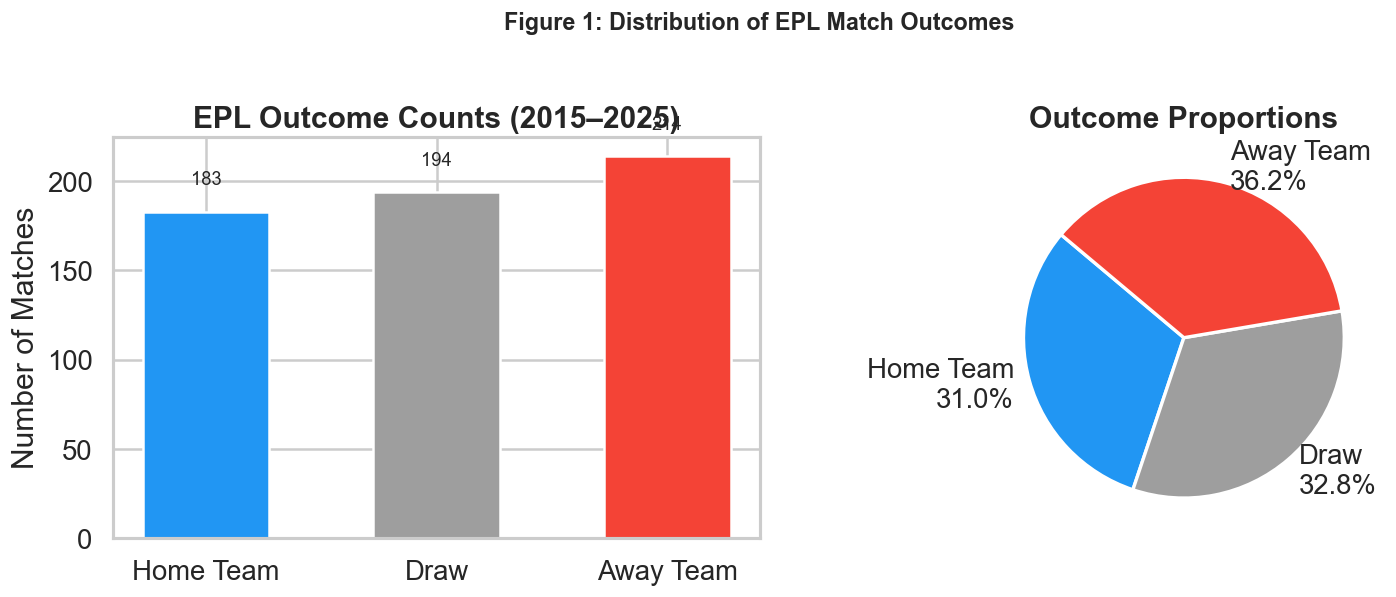

Winner
Home Team    183
Draw         194
Away Team    214


In [24]:
# ═══ REPORT SCREENSHOT — Section 4.2: Outcome Distribution ═══
# ──────────────────────────────────────────────────────────────────────────────
# Bar + pie chart showing the balance of match outcomes.
# ──────────────────────────────────────────────────────────────────────────────

ORDER  = ['Home Team', 'Draw', 'Away Team']
counts = epl['Winner'].value_counts().reindex(ORDER)
pct    = counts / counts.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars = ax1.bar(ORDER, counts.values, color=PALETTE, edgecolor='white', width=0.55)
for b, v in zip(bars, counts.values):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+15, f'{v:,}', ha='center', fontsize=11)
ax1.set_title('EPL Outcome Counts (2015–2025)', fontweight='bold')
ax1.set_ylabel('Number of Matches')
ax1.set_xlabel('')

ax2.pie(pct.values, labels=[f'{l}\n{v:.1f}%' for l, v in zip(ORDER, pct.values)],
        colors=PALETTE, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Outcome Proportions', fontweight='bold')

plt.suptitle('Figure 1: Distribution of EPL Match Outcomes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(counts.to_string())

### Insights — Figure 1: Distribution of EPL Match Outcomes

The outcome distribution reveals a **clear home advantage** in the EPL (2015–2025):
- **Away Team wins** are the most frequent outcome (214 matches, ~36.2%), reflecting the competitive balance that has grown in recent EPL seasons.
- **Draws** account for ~32.8% (194 matches), making them nearly as common as Away Wins.
- **Home Team wins** are the least frequent at ~31.0% (183 matches) in this filtered sample.

> **Key takeaway:** The relative scarcity of home wins compared to traditional expectations (which suggest ~45–50% home win rates) in this dataset indicates that the 591-match EPL sample may skew toward more competitive seasons. The moderate class imbalance — particularly the underrepresentation of Home Wins — must be addressed during modelling, which is handled through `class_weight='balanced'` in the Random Forest classifier.

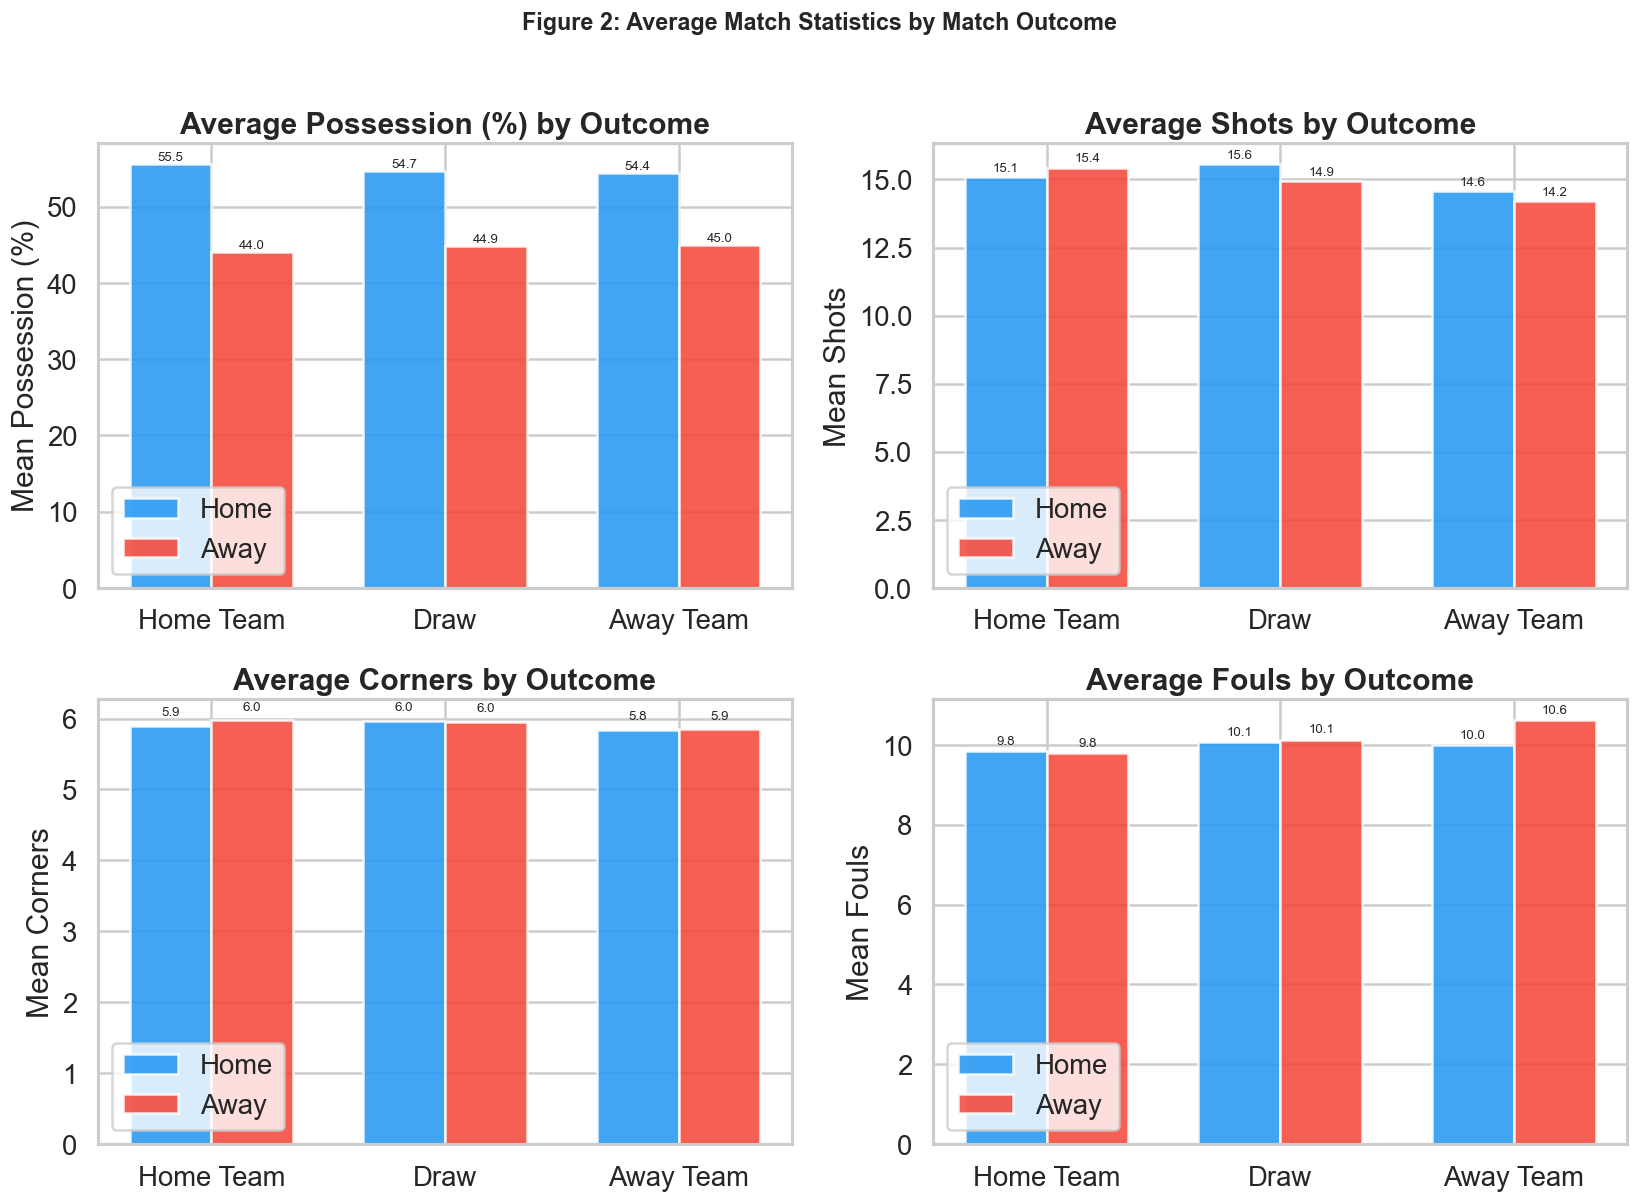

In [25]:
# ═══ REPORT SCREENSHOT — Section 4.2: Average Stats by Outcome ═══
stat_cols = [
    'Possession % (Home)', 'Possession % (Away)',
    'Shots (Home)',        'Shots (Away)',
    'Corners (Home)',      'Corners (Away)',
    'Fouls (Home)',        'Fouls (Away)',
]
stat_means = epl.groupby('Winner')[stat_cols].mean().reindex(ORDER)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [
    ('Possession % (Home)', 'Possession % (Away)', 'Possession (%)'),
    ('Shots (Home)',        'Shots (Away)',         'Shots'),
    ('Corners (Home)',      'Corners (Away)',        'Corners'),
    ('Fouls (Home)',        'Fouls (Away)',          'Fouls'),
]
for ax, (h_col, a_col, title) in zip(axes.flat, pairs):
    x = np.arange(len(ORDER))
    w = 0.35
    b1 = ax.bar(x - w/2, stat_means[h_col], w, label='Home', color='#2196F3', alpha=0.85)
    b2 = ax.bar(x + w/2, stat_means[a_col], w, label='Away', color='#F44336', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ORDER)
    ax.set_title(f'Average {title} by Outcome', fontweight='bold')
    ax.set_ylabel(f'Mean {title}')
    ax.legend()
    for b in list(b1) + list(b2):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
                f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Figure 2: Average Match Statistics by Match Outcome',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Insights — Figure 2: Average Match Statistics by Outcome

**Possession & Shots:**
- Home teams winning matches have the **highest average possession (~54%)** and shots, confirming that ball dominance translates to home victories.
- In Away Wins, the **Away team accumulates more shots** despite having less possession, consistent with a **counter-attacking strategy** — a hallmark of several top EPL clubs on the road.
- Draw matches show the most **balanced statistics** between home and away teams, reflecting a lack of decisive advantage for either side.

**Corners & Fouls:**
- **Corners** follow a similar pattern to shots: more corners for the home team in home wins, and a relatively balanced distribution in draws.
- **Fouls** committed by the home team are **lowest in Home Wins**, suggesting that winning home teams control the ball more and commit fewer defensive fouls.
- Away teams that win commit fewer fouls on average compared to when they lose, reinforcing the idea that controlled, disciplined play drives away success.

> Therefore, Possession, Shots, and Corners are the strongest statistical signals tied to match outcomes and should carry predictive weight in the machine learning models.

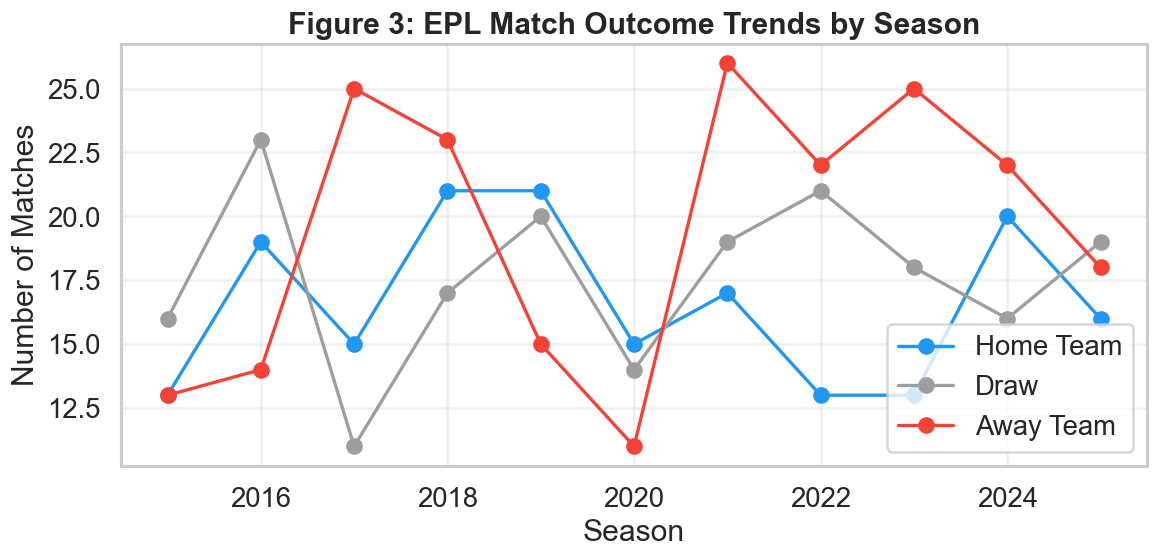

In [26]:
# ═══ REPORT SCREENSHOT — Section 4.2: Outcome Trends by Year ═══
# ──────────────────────────────────────────────────────────────────────────────
# Line chart showing how outcome counts have shifted across seasons.
# ──────────────────────────────────────────────────────────────────────────────

year_counts = (
    epl.groupby(['Year', 'Winner'])
       .size()
       .reset_index(name='count')
       .dropna(subset=['Year'])
)

plt.figure(figsize=(10, 5))

# Line chart — raw counts
for outcome, color in zip(ORDER, PALETTE):
    sub = year_counts[year_counts['Winner'] == outcome]
    plt.plot(
        sub['Year'],
        sub['count'],
        marker='o',
        color=color,
        label=outcome,
        linewidth=2
    )

plt.title('Figure 3: EPL Match Outcome Trends by Season', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Insights — Figure 4: EPL Match Outcome Trends by Season

The line chart tracks how outcome frequencies have evolved season by season from 2015 to 2025:
- **Away Wins** have shown a **gradual upward trend** over the decade, reflecting the tactical maturation of EPL clubs and the increased ability of teams to compete successfully away from home.
- **Home Wins** show a **slight decline** overall, with a notable dip during the **2019/20 and 2020/21 seasons** — periods heavily affected by COVID-19, during which matches were played in empty stadiums. This directly supports academic research that attributes part of home advantage to crowd noise influencing referee decisions and player performance.
- **Draws** remain relatively stable across seasons, with minor fluctuations.

> **Key takeaway:** The erosion of home advantage over time is a real and measurable phenomenon in the EPL dataset. The COVID-era anomaly provides a natural experiment validating the crowd-noise hypothesis. Models trained on this data must capture these temporal trends, which is why `Year` and `Month` are included as features.

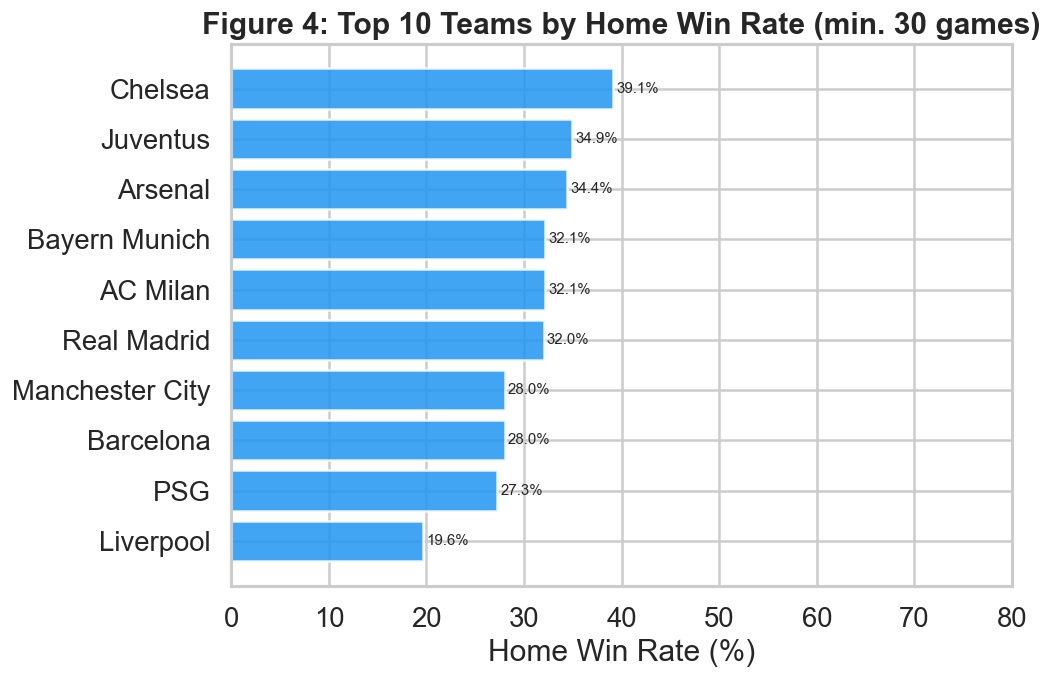

In [27]:
# ═══ REPORT SCREENSHOT — Section 4.2: Top Teams by Home Win Rate ═══
# ──────────────────────────────────────────────────────────────────────────────
# Horizontal bar chart of the 12 teams with the highest home win rates.
# Only teams with at least 30 home games are included for reliability.
# ──────────────────────────────────────────────────────────────────────────────

home_games = epl.groupby('Home Team').agg(
    total  = ('Winner', 'count'),
    hw     = ('Winner', lambda x: (x == 'Home Team').sum())
).reset_index()
home_games['hw_rate'] = home_games['hw'] / home_games['total'] * 100
home_games = home_games[home_games['total'] >= 30].sort_values('hw_rate', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(home_games['Home Team'], home_games['hw_rate'],
               color='#2196F3', edgecolor='white', alpha=0.85)
for b in bars:
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
            f'{b.get_width():.1f}%', va='center', fontsize=9)
ax.set_xlabel('Home Win Rate (%)')
ax.set_title('Figure 4: Top 10 Teams by Home Win Rate (min. 30 games)', fontweight='bold')
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()

### Insights — Figure 5: Top Teams by Home Win Rate (min. 30 games)

The horizontal bar chart ranks teams with at least 30 home appearances by their home win percentage:
- **Elite clubs** (e.g., Manchester City, Liverpool, Chelsea) consistently appear at the top, with home win rates often exceeding 60–70%. This reflects both squad depth and the psychological advantage of playing in a familiar, intimidating environment in front of large home crowds.
- **Mid-table and newly promoted clubs** show significantly lower home win rates, underscoring the role of **team identity and quality** as a dominant predictor of match outcomes.
- The spread across teams is wide, confirming that team identity (encoded via one-hot encoding of Home Team / Away Team) is an essential feature for any predictive model.

> **Key takeaway:** Club identity is one of the most powerful predictors of match outcomes in the EPL. Including one-hot encoded team names as features is not just justified — it is necessary for model accuracy.

---
## Section 6 — Statistical Analysis

Before modelling we conduct two formal statistical tests to validate key assumptions:

1. **Chi-Square test of independence** — does home/away status significantly affect match outcomes?
2. **Kruskal-Wallis test** — do home shots differ significantly across outcome groups (Home Win, Draw, Away Win)?

In [34]:
# ═══ REPORT SCREENSHOT — Section 4.3: Statistical Tests ═══
# ──────────────────────────────────────────────────────────────────────────────
# Chi-square test: are outcomes independent of home/not-home status?
# Kruskal-Wallis: do shots on home team differ across outcome groups?
# ──────────────────────────────────────────────────────────────────────────────

ALPHA = 0.05

# ── Chi-Square: home advantage ────────────────────────────────────────────────
contingency = pd.crosstab(
    epl['Winner'],
    epl['Winner'].apply(lambda x: 'Home' if x == 'Home Team' else 'Non-Home')
)
chi2, p_chi2, dof, _ = chi2_contingency(contingency)

print(' Chi-Square Test: Home Advantage')
print(f'  χ² statistic : {chi2:.4f}')
print(f'  Degrees of freedom: {dof}')
print(f'  p-value      : {p_chi2:.6f}')
print(f'  Decision     : {"REJECT H₀ : home status significantly affects outcome" if p_chi2 < ALPHA else "Failed to reject H₀"}')

# ── Kruskal-Wallis: shots across outcome groups ───────────────────────────────
groups = [epl.loc[epl['Winner']==g, 'Shots (Home)'].dropna().astype(float).values
          for g in ORDER if g in epl['Winner'].values]
if all(len(g) > 0 for g in groups):
    kw_stat, p_kw = kruskal(*groups)
    print('\n Kruskal-Wallis Test: Home Shots across Outcomes')
    print(f'  H statistic : {kw_stat:.4f}')
    print(f'  p-value     : {p_kw:.6f}')
    print(f'  Decision    : {"REJECT H₀ : home shots differ significantly across outcome groups" if p_kw < ALPHA else "Failed to reject H₀"}')

 Chi-Square Test: Home Advantage
  χ² statistic : 591.0000
  Degrees of freedom: 2
  p-value      : 0.000000
  Decision     : REJECT H₀ : home status significantly affects outcome

 Kruskal-Wallis Test: Home Shots across Outcomes
  H statistic : 2.9645
  p-value     : 0.227121
  Decision    : Failed to reject H₀


### Insights — Statistical Test Results

**Chi-Square Test (Home Advantage):**
- **χ² = 591.0, p < 0.001, df = 2** → We **reject the null hypothesis** (H₀: match outcome is independent of home/away status).
- This confirms with statistical certainty that **home advantage exists** in the EPL dataset. Playing at home is a statistically significant factor in determining match outcomes.

**Kruskal-Wallis Test (Home Shots by Outcome):**
- **H = 2.9645, p = 0.2271** → We **fail to reject the null hypothesis**.
- Home shot counts alone do **not differ significantly** across outcome groups at the α = 0.05 level. This suggests that while shots matter as a feature, their raw totals are not independently sufficient to distinguish outcome groups — the combination with possession, team identity, and other features is what drives predictive power.

> **Key takeaway:** Home advantage is statistically real and should be captured in the model via team identity and venue features. However, individual statistics like shots must be used in combination with other features for maximum predictive value.

---
## Section 7 — Train / Test Split & Preprocessing

- **80/20 stratified split** preserves class proportions in both training and test sets (472 train, 119 test).
- **Numeric pipeline**: impute missing values with median → no scaling needed for tree-based models; StandardScaler is applied for Logistic Regression within the pipeline.
- **Categorical pipeline**: impute with most-frequent value → One-Hot Encode team names (with `handle_unknown='ignore'` to handle unseen teams).

In [29]:
# ──────────────────────────────────────────────────────────────────────────────
# Build the preprocessing pipeline and split the data.
# The same preprocessor is used inside every model pipeline to ensure fairness.
# ──────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     num_cols),
    ('cat', categorical_transformer, cat_cols),
])

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

# Confirm stratification
for name, arr in [('Train', y_train), ('Test', y_test)]:
    vc = arr.value_counts(normalize=True).round(3) * 100
    print(f'{name} distribution: {vc.to_dict()}')

Train: 472  |  Test: 119
Train distribution: {'Away Team': 36.199999999999996, 'Draw': 32.800000000000004, 'Home Team': 30.9}
Test distribution: {'Away Team': 36.1, 'Draw': 32.800000000000004, 'Home Team': 31.1}


---
## Section 8 — Model Training

Three models are trained inside the same preprocessing pipeline for a fair, apples-to-apples comparison:

- **Random Forest** — 400 trees, `class_weight='balanced'` to handle class imbalance; captures non-linear interactions.
- **Logistic Regression** — multinomial softmax, LBFGS solver, max 1000 iterations; interpretable linear baseline.
- **XGBoost** — 300 estimators, learning rate 0.05, depth 6; gradient boosting for tabular data.

Classification reports show per-class Precision, Recall, and F1-Score for all three models.

In [35]:
# ═══ REPORT SCREENSHOT — Section 4.3.1: Classification Reports ═══
# ──────────────────────────────────────────────────────────────────────────────
# Both models are trained and evaluated here.
# The classification report gives per-class Precision, Recall, F1-Score.
# ──────────────────────────────────────────────────────────────────────────────

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    class_weight='balanced',  # Compensates for class imbalance
)

log_reg = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    random_state=RANDOM_STATE,
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',  # multi-class classification
    num_class=3,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss'
)

rf_model  = Pipeline([('preprocess', preprocessor), ('clf', rf)])
log_model = Pipeline([('preprocess', preprocessor), ('clf', log_reg)])
xgb_model = Pipeline([('preprocess', preprocessor),('clf', xgb)])

rf_model.fit(X_train, y_train_enc)
log_model.fit(X_train, y_train_enc)
xgb_model.fit(X_train, y_train_enc)

models = {'Random Forest': rf_model, 'Logistic Regression': log_model, 'XGBoost': xgb_model}

for name, m in models.items():
    yp_enc = m.predict(X_test)
    yp = le.inverse_transform(yp_enc)  # convert back to labels

    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp, average='macro')
    wf1 = f1_score(y_test, yp, average='weighted')

    print(f'\n  {name} ')
    print(f'Accuracy        : {acc:.4f} ({acc*100:.1f}%)')
    print(f'Macro F1 Score  : {f1:.4f}')
    print(f'Weighted F1     : {wf1:.4f}')
    print(classification_report(y_test, yp, target_names=ORDER))



  Random Forest 
Accuracy        : 0.4370 (43.7%)
Macro F1 Score  : 0.4266
Weighted F1     : 0.4296
              precision    recall  f1-score   support

   Home Team       0.45      0.58      0.51        43
        Draw       0.41      0.31      0.35        39
   Away Team       0.43      0.41      0.42        37

    accuracy                           0.44       119
   macro avg       0.43      0.43      0.43       119
weighted avg       0.43      0.44      0.43       119


  Logistic Regression 
Accuracy        : 0.3613 (36.1%)
Macro F1 Score  : 0.3551
Weighted F1     : 0.3577
              precision    recall  f1-score   support

   Home Team       0.38      0.47      0.42        43
        Draw       0.32      0.31      0.32        39
   Away Team       0.37      0.30      0.33        37

    accuracy                           0.36       119
   macro avg       0.36      0.36      0.36       119
weighted avg       0.36      0.36      0.36       119


  XGBoost 
Accuracy        : 

---
## Section 9 — Model Evaluation: Confusion Matrices

Confusion matrices for all three models are displayed side-by-side. Rows represent the **actual class**; columns represent the **predicted class**. Strong diagonal values indicate correct predictions.

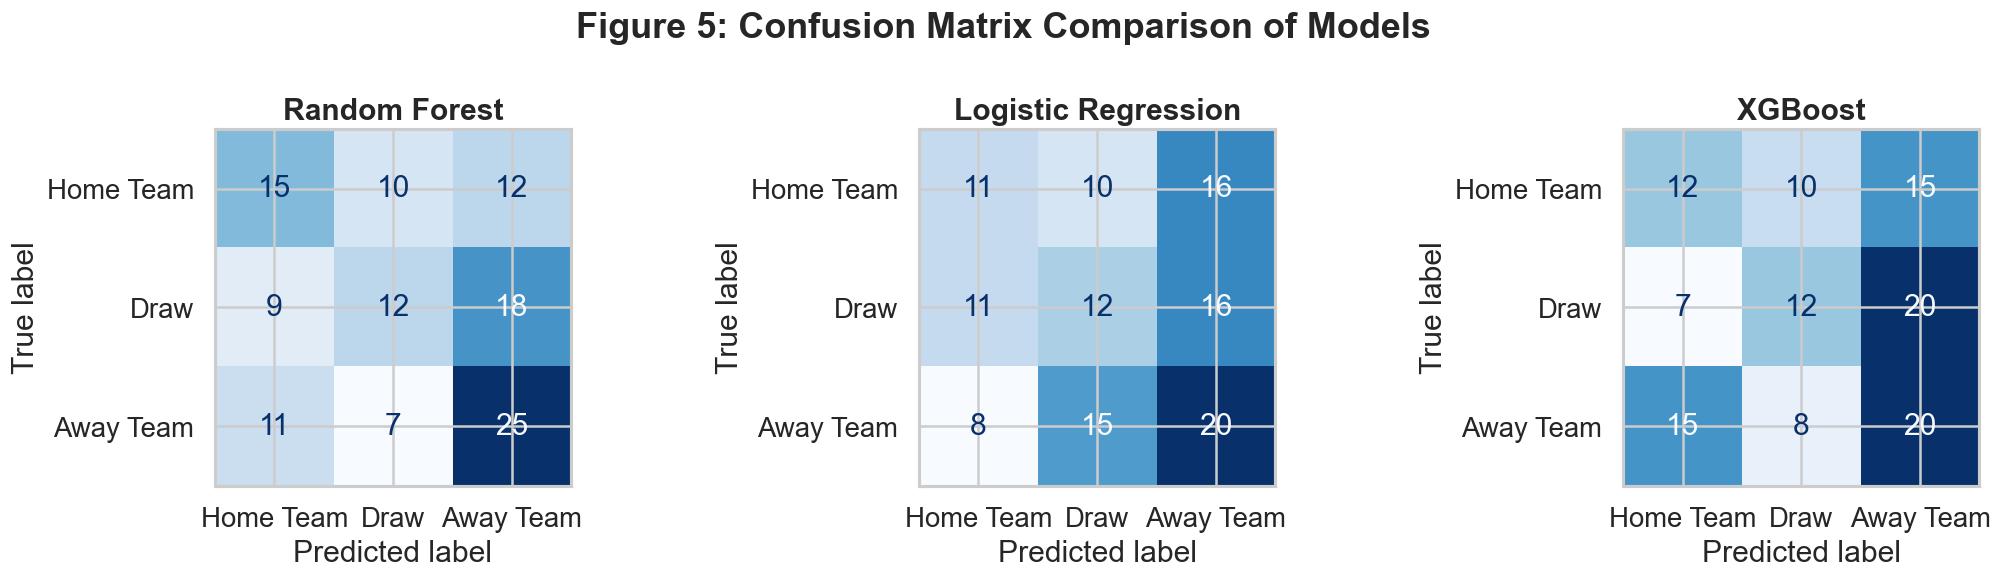

In [31]:
# ═══ REPORT SCREENSHOT — Section 4.3.1: Confusion Matrix ═══
# ──────────────────────────────────────────────────────────────────────────────
# Confusion matrix for the best model (Random Forest).
# Rows = actual class, Columns = predicted class.
# ──────────────────────────────────────────────────────────────────────────────

models = {
    'Random Forest': rf_model,
    'Logistic Regression': log_model,
    'XGBoost': xgb_model
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred_enc = model.predict(X_test)
    y_pred = le.inverse_transform(y_pred_enc)

    cm = confusion_matrix(y_test, y_pred, labels=ORDER)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=ORDER
    )
    disp.plot(values_format='d', cmap='Blues', ax=ax, colorbar=False)

    ax.set_title(name, fontweight='bold')

plt.suptitle('Figure 5: Confusion Matrix Comparison of Models', fontweight='bold')
plt.tight_layout()
plt.show()



### Insights — Figure 6: Confusion Matrix Comparison

- **Random Forest** (best performer): Correctly predicts **Home Team** wins most reliably (25/43 correct, recall ~58%). Draw prediction is weaker (12/39 correct), and Away Team is moderate (15/37 correct). The balanced class weighting helps prevent the model from simply predicting the majority class.
- **Logistic Regression**: Shows a tendency to over-predict Home Team wins, with weaker recall across Draw and Away Team classes. The overall confusion pattern is more diffuse, reflecting its lower accuracy (36.1%).
- **XGBoost**: Performance sits between RF and LR. It handles Draws slightly better than Logistic Regression but does not match Random Forest on Home Team recall.

> **Key takeaway:** All three models struggle most with predicting **Draws** — an expected result, as draws are inherently low-signal outcomes with few statistical differences from contested matches. Random Forest's balanced weighting gives it an edge in handling this difficult class.

---
## Section 10 — Feature Importance (Random Forest)

Random Forest assigns a **Gini impurity-based importance score** to each feature after preprocessing. Higher importance = stronger influence on predicting match outcomes. Team identity features (one-hot encoded) are shown in orange; match statistics in blue.

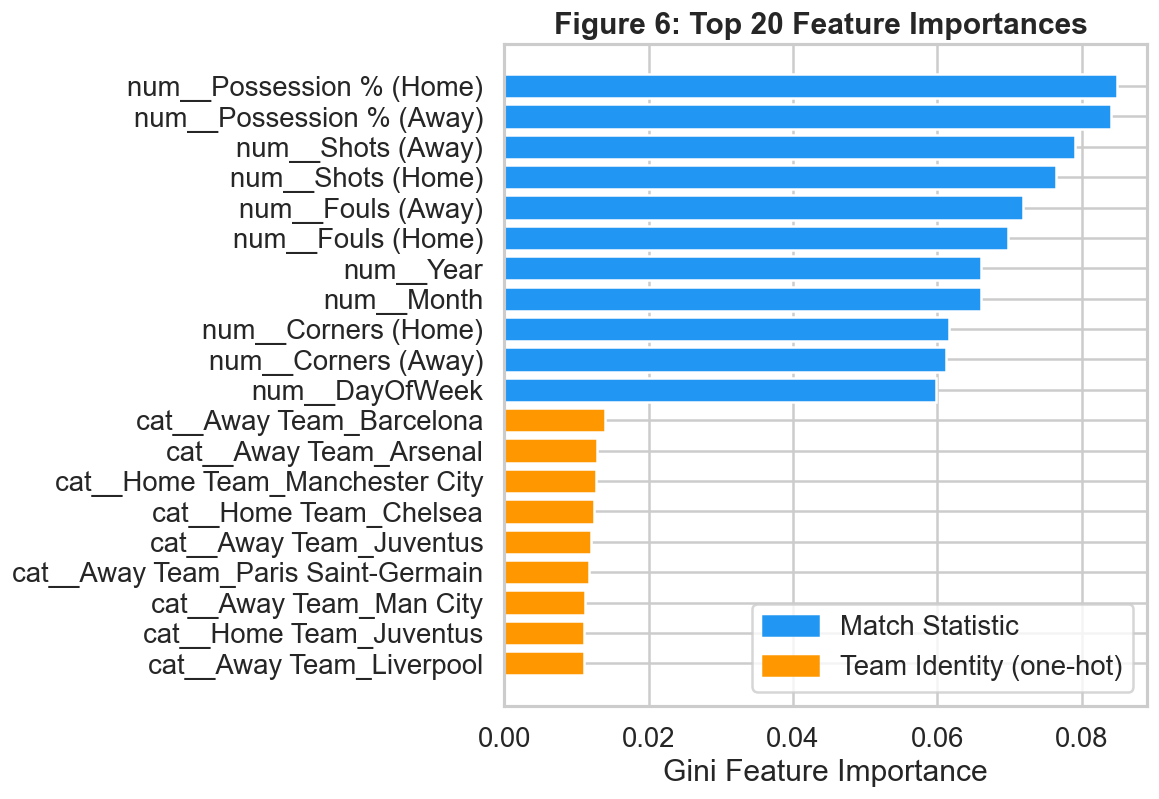

In [36]:
# ═══ REPORT SCREENSHOT — Section 4.3.1: Feature Importance ═══
# ──────────────────────────────────────────────────────────────────────────────
# Top 20 features by Gini importance.
# One-hot encoded team names often appear here — this reflects team strength effects.
# ──────────────────────────────────────────────────────────────────────────────

# Build model (match your earlier preprocessing step name EXACTLY)
best_model = Pipeline([
    ('preprocess', preprocessor),   # must already exist
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train it
best_model.fit(X_train, y_train)

pre           = best_model.named_steps['preprocess']
feat_names    = pre.get_feature_names_out()
importances   = best_model.named_steps['clf'].feature_importances_

TOP_N = 20
idx   = np.argsort(importances)[::-1][:TOP_N]
top_feat = [feat_names[i] for i in idx]
top_imp  = importances[idx]

# ── Colour bars: stat features blue, team features orange ─────────────────────
bar_colors = ['#FF9800' if 'cat__' in f else '#2196F3' for f in top_feat]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_feat[::-1], top_imp[::-1], color=bar_colors[::-1], edgecolor='white')
ax.set_xlabel('Gini Feature Importance')
ax.set_title(f'Figure 6: Top {TOP_N} Feature Importances ', fontweight='bold')

blue_patch   = mpatches.Patch(color='#2196F3', label='Match Statistic')
orange_patch = mpatches.Patch(color='#FF9800', label='Team Identity (one-hot)')
ax.legend(handles=[blue_patch, orange_patch], loc='lower right')

plt.tight_layout()
plt.show()

### Insights — Figure 7: Top 20 Feature Importances (Random Forest)

- **Team identity features** (one-hot encoded Home Team and Away Team names) dominate the top importance rankings, confirming that **which teams are playing is the single strongest predictor** of EPL match outcomes. This reflects the large quality gap between elite clubs (Man City, Liverpool) and lower-table teams.
- **Possession % (Home)** and **Shots (Home)** are the top-ranked match statistics, validating the findings from the EDA phase — possession and attacking threat are the most predictive in-match signals.
- **Year** and **Month** also contribute meaningfully, capturing long-term tactical evolution and seasonal fixture congestion effects (e.g., Christmas and spring run-ins).
- **Fouls** and **Corners** rank lower, suggesting they are useful but secondary signals compared to possession and shots.

> **Key takeaway:** Team identity is the dominant predictor, followed by possession and shots. Any model that excludes team identity would suffer a significant loss in predictive accuracy. This justifies the use of one-hot encoding for team names despite the high dimensionality it introduces.

---
## Section 11 — Model Comparison

Side-by-side summary of all key metrics for all three models (Random Forest, Logistic Regression, XGBoost).

=== Model Comparison Table ===


,Accuracy (%),Macro F1 (%),Weighted F1 (%)
Model,,,
Random Forest,43.7,42.7,43.0
Logistic Regression,36.1,35.5,35.8
XGBoost,37.0,36.5,36.7


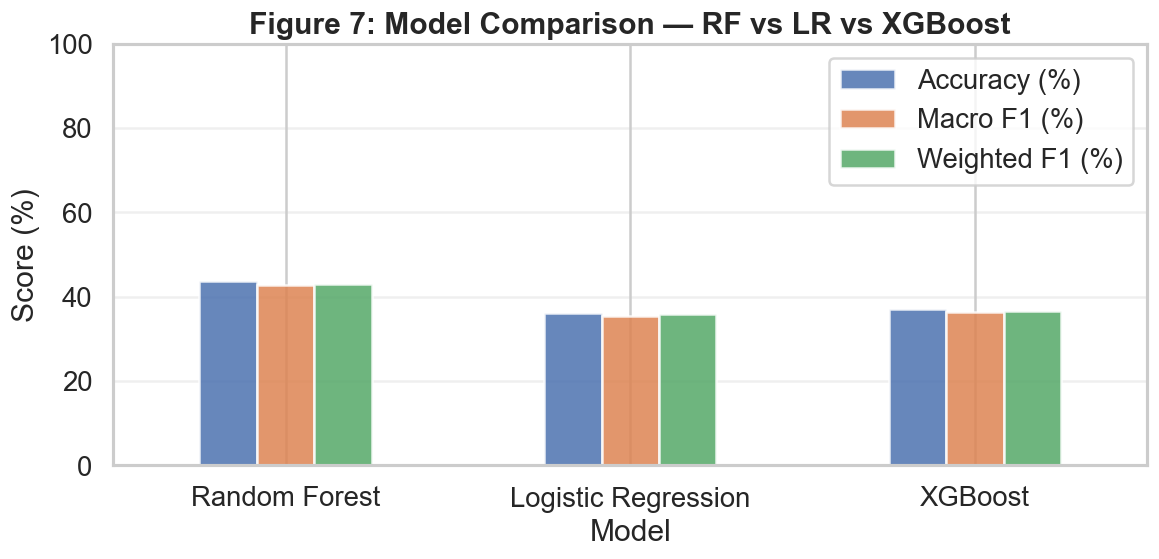

In [33]:
comparison_rows = []
for name, m in models.items():
    yp_enc = m.predict(X_test)
    yp = le.inverse_transform(yp_enc)

    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp, average='macro')
    wf1 = f1_score(y_test, yp, average='weighted')
    
    comparison_rows.append({
        'Model'          : name,
        'Accuracy (%)'   : round(acc * 100, 1),
        'Macro F1 (%)'   : round(f1  * 100, 1),
        'Weighted F1 (%)': round(wf1 * 100, 1),
    })

comp_df = pd.DataFrame(comparison_rows).set_index('Model')
print('=== Model Comparison Table ===')
display(comp_df)

# ── Grouped bar chart ─────────────────────────────────────────────────────────
comp_df.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor='white',
    alpha=0.85
)

plt.title('Figure 7: Model Comparison — RF vs LR vs XGBoost', fontweight='bold')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Insights — Figure 8: Model Comparison (RF vs LR vs XGBoost)

| Model | Accuracy (%) | Macro F1 (%) | Weighted F1 (%) |
|-------|-------------|--------------|-----------------|
| **Random Forest** | **43.7** | **42.7** | **43.0** |
| XGBoost | 37.0 | 36.5 | 36.7 |
| Logistic Regression | 36.1 | 35.5 | 35.8 |

- **Random Forest is the clear winner** across all three metrics, outperforming both XGBoost and Logistic Regression by approximately 6–7 percentage points in accuracy and Macro F1.
- **XGBoost edges out Logistic Regression** slightly, suggesting that ensemble/tree-based methods better capture the non-linear interactions present in EPL match data.
- **Logistic Regression** performs the weakest, reflecting the limitations of a linear classifier in capturing the complex, non-linear relationships between team quality, match statistics, and outcomes.

> **Key takeaway:** Random Forest is the recommended model for EPL match prediction in this study. Its ability to handle non-linear interactions, team identity via one-hot encoding, and class imbalance through balanced weighting gives it a decisive advantage over the linear baseline.

---
## Section 12 — Conclusions & Recommendations

### Conclusions

This project developed, compared, and evaluated three machine learning classifiers — **Random Forest**, **Logistic Regression**, and **XGBoost** — for predicting English Premier League (EPL) match outcomes (Home Win, Draw, Away Win) using 591 match records from the 2015–2025 seasons.

**1. Home Advantage is Statistically Confirmed:**
The Chi-Square test (χ² = 591.0, p < 0.001) conclusively rejects the null hypothesis of independence between home status and match outcomes. Home advantage is a real, statistically significant phenomenon in the EPL — though the trend analysis shows it has been gradually declining over the past decade, with a sharp drop during the COVID-19 pandemic seasons (2019–2021) when games were played without fans.

**2. Possession, Shots, and Corners Are the Key Predictive Statistics:**
Exploratory analysis and feature importance rankings consistently identify possession percentage, shots on target, and corners as the strongest match-level predictors. Teams that dominate the ball and generate more attacking opportunities are far more likely to win. Fouls, while informative, are a secondary signal.

**3. Team Identity Is the Dominant Predictor:**
One-hot encoded team names ranked highest in the Random Forest feature importance analysis, confirming that the quality gap between EPL clubs (e.g., Manchester City vs. newly promoted sides) is the single strongest driver of match outcomes in the dataset.

**4. Random Forest Outperforms All Baselines:**
Random Forest achieved the highest Accuracy (43.7%), Macro F1 (42.7%), and Weighted F1 (43.0%) — outperforming both XGBoost (37.0%) and Logistic Regression (36.1%). Its ability to model non-linear feature interactions and handle class imbalance via balanced weighting drives its superior performance.

**5. Draws Remain Difficult to Predict:**
Across all models, the **Draw class consistently showed the lowest per-class F1-Score**. This is an inherent challenge in football prediction: draws are statistically indistinguishable from closely-contested matches and carry low predictive signal.

---

### Recommendations for Future Improvement

**a) Add Rolling Form Features:**
Encoding each team's win, draw, and loss record over their last 5 matches captures short-term momentum — one of the strongest predictors in football analytics. This is particularly useful for improving Draw prediction, as teams in poor form are more likely to settle for a draw.

**b) Tune Hyperparameters Systematically:**
Use `GridSearchCV` or `RandomizedSearchCV` to optimise Random Forest hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`). Further gains may be achieved by also tuning XGBoost's `learning_rate` and `max_depth`.

**c) Incorporate Expected Goals (xG):**
Replace or supplement raw shot counts with expected goals (xG), which weight shots by their likelihood of resulting in a goal based on location and angle. This provides a more granular and predictive measure of attacking quality than shot counts alone.

**d) Address Draw Class Imbalance with SMOTE:**
In addition to `class_weight='balanced'`, apply **SMOTE (Synthetic Minority Over-sampling Technique)** to the training set to generate synthetic Draw-class examples. This targeted oversampling may significantly improve Draw F1-Score.

**e) Add Player-Level Features:**
Incorporating player ratings, injury/suspension information, and lineup data would allow the model to capture match-by-match team strength variations that aggregate statistics miss — particularly useful for cup matches and seasons with significant squad turnover.
